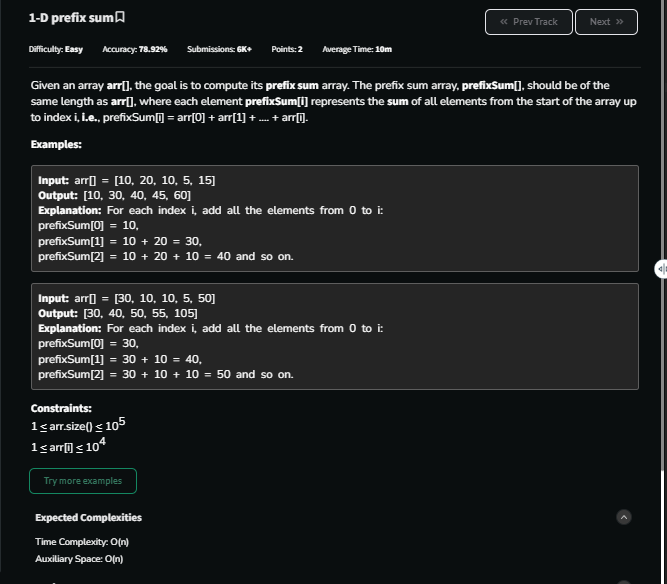

In [ ]:
class Solution:
    def prefSum(self, arr):
        prefixSum=[]
        sum=0
        for i in range(len(arr)):
            sum+=arr[i]
            prefixSum.append(sum)
        return prefixSum


In [1]:
class Solution:
    def prefSum(self, arr):
        prefixSum=[]
        prefixSum.append(arr[0])
        # sum=0
        for i in range(1,len(arr)):
            # sum+=arr[i]
            prefixSum.append(prefixSum[i-1]+arr[i])
        return prefixSum
solution=Solution()
print(solution.prefSum([0,1,2,3,4,5]))

[0, 1, 3, 6, 10, 15]


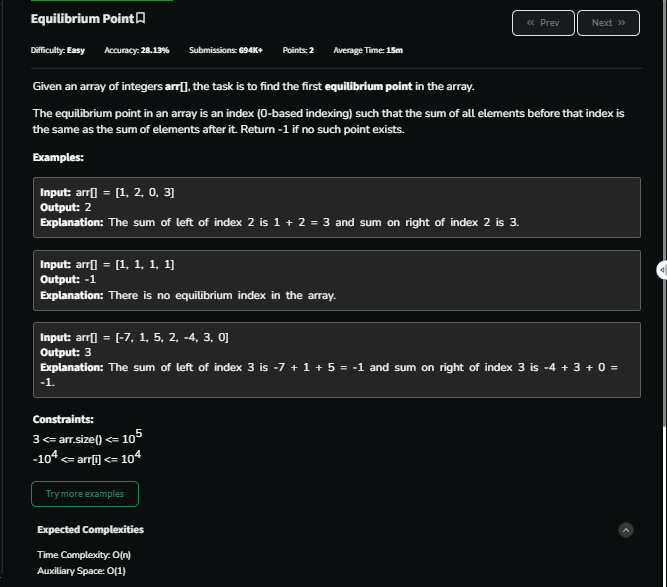

In [ ]:
# Euillibrium point 

# Brute Force

class Solution:
    def findEquilibrium(self, arr):
        
        for i in range(1, len(arr)-1):
            sum_l=0
            sum_r=0 
            for j in range(0,i):
                sum_l+=arr[j]
            for k in range(i+1,len(arr)):
                sum_r+=arr[k]
            if sum_l==sum_r:
                return i
                
        return -1

In [3]:
# Optimal Solution (Using prefix sum)

class Solution:
    def findEquilibrium(self, arr):
        
        # Make Prefix Array

        prefix=[]
        prefix.append(arr[0])
        for i in range(1,len(arr)):
            prefix.append(prefix[i-1]+arr[i])
        # print(prefix[0])
        # return prefix

        # Make Suffix Array

        suffix=[0]*(len(arr))
        # print(suffix)
        suffix[len(suffix)-1]=arr[len(arr)-1]
        # print(suffix)
        for i in range(len(arr)-2,-1,-1):
            suffix[i]=suffix[i+1]+arr[i]
        # print(suffix[0])
        # return suffix

        lsum=0
        rsum=0
        
        for i in range(0,len(arr)-1):
            # if i==0 and suffix[i]==0:
            #     return i
            lsum=prefix[i-1]
            rsum=suffix[i+1]
        # print(lsum)
        # print(rsum)
            if lsum==rsum:
                return i
        
        return -1

soln=Solution()
print(soln.findEquilibrium([-7, 1, 5 ,2 ,-4, 3, 0]))

3


In [1]:
# home work approach :

class Solution:
    def findEquilibrium(self, arr):
        total = sum(arr)
        prefix = 0

        for i in range(len(arr)):
            suffix = total - prefix - arr[i]

            if prefix == suffix:
                return i
            
            prefix += arr[i]

        return -1

soln=Solution()
print(soln.findEquilibrium([-7, 1, 5 ,2 ,-4, 3, 0]))

3


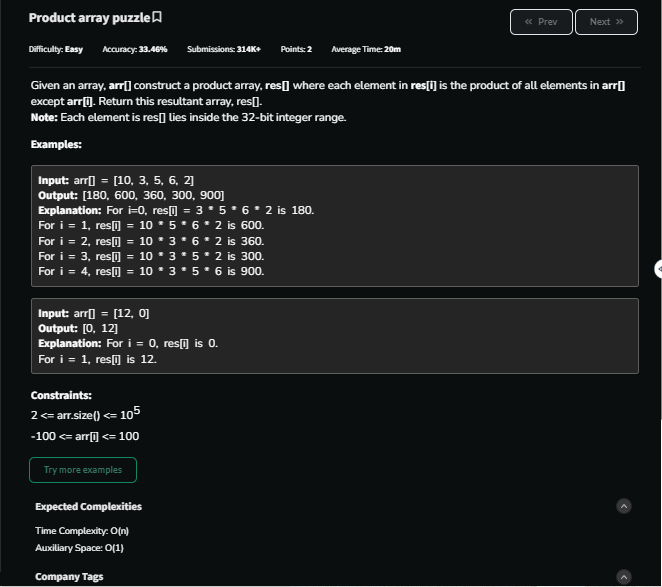

In [ ]:
class Solution:
    def productExceptSelf(self, arr):
        # code here

        # Make prefix product
        
        n = len(arr)
        preprod=[0]*(n)
        # return preprod
        preprod[0]=arr[0]
        # return preprod
        for i in range(1,n):
            preprod[i]=preprod[i-1]*arr[i]
        # return preprod
        
        # Make suffix product
        
        sprod =[0]*n
        sprod[n-1]=arr[n-1]
        
        for i in range(n-2,-1,-1):
            sprod[i]=sprod[i+1]*arr[i]
        # return sprod
        
        res=[0]*len(preprod)
        
        # res first element
        res[0]=sprod[1]
        # res final element
        res[len(res)-1]=preprod[len(preprod)-2]
        
        
        for i in range(1,len(res)-1):
            res[i]=preprod[i-1]*sprod[i+1]
        return res

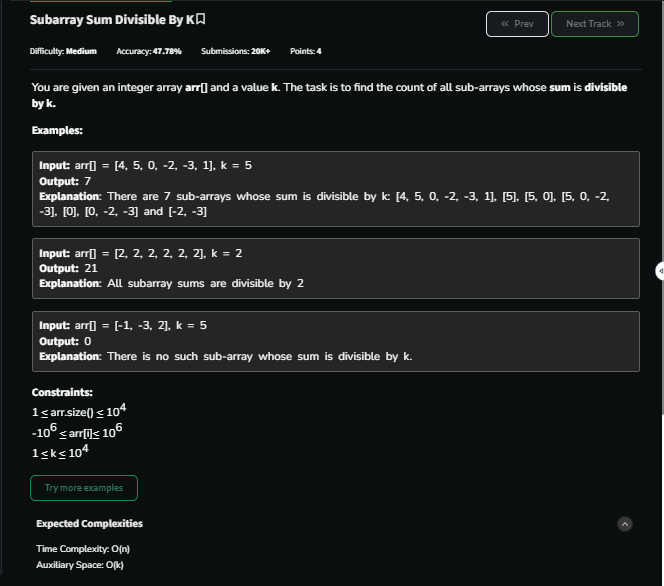

step-by-step dry run of your brute-force algorithm for the array arr = [1, -3, 5, 2].


Algorithm Logic


Your code iterates through each number (num) in the array. For each number:

It takes all subarray sums ending at the previous position (ending_here), adds the current num to them, 

and stores them in new_ending. 

It adds the current num itself (starting a new subarray) to new_ending.

It updates ending_here to new_ending for the next iteration.

It extends the master list all_sums with these new sums.

| Iteration | Current `num` | Previous `ending_here` | Calculation (`s + num` for each `s`) | New Subarray (`num`) | `new_ending` (Result) | Updated `ending_here` | `all_sums` (Cumulative) |
| :--- | :---: | :--- | :--- | :---: | :--- | :--- | :--- |
| **1** | `1` | `[]` | *(none)* | `1` | `[1]` | `[1]` | `[1]` |
| **2** | `-3` | `[1]` | `1 + (-3) = -2` | `-3` | `[-2, -3]` | `[-2, -3]` | `[1, -2, -3]` |
| **3** | `5` | `[-2, -3]` | `-2 + 5 = 3`<br>`-3 + 5 = 2` | `5` | `[3, 2, 5]` | `[3, 2, 5]` | `[1, -2, -3, 3, 2, 5]` |
| **4** | `2` | `[3, 2, 5]` | `3 + 2 = 5`<br>`2 + 2 = 4`<br>`5 + 2 = 7` | `2` | `[5, 4, 7, 2]` | `[5, 4, 7, 2]` | `[1, -2, -3, 3, 2, 5, 5, 4, 7, 2]` |

In [ ]:
# Brute Force - computing all the subarray sums then finding how many of those are divisible by K.
# Note : all subarray sums can also be computed using Recursion

arr = [1,-3,5,2]
k = 5

all_sums = []

ending_here = []

for num in arr:

    new_ending = []

    new_ending.append(num)

    for s in ending_here:
        new_ending.append(s + num)

    ending_here = new_ending

    all_sums.extend(ending_here)

    # print(new_ending)
    # print(ending_here)
    # print(all_sums)

print(all_sums)

count = 0
for num in all_sums:
    if num % k == 0:
        count += 1

print(count)


[1]
[1]
[1]
[-3, -2]
[-3, -2]
[1, -3, -2]
[5, 2, 3]
[5, 2, 3]
[1, -3, -2, 5, 2, 3]
[2, 7, 4, 5]
[2, 7, 4, 5]
[1, -3, -2, 5, 2, 3, 2, 7, 4, 5]
[1, -3, -2, 5, 2, 3, 2, 7, 4, 5]
2


core logic:

    The algorithm relies on the property: if prefix_sum[i] % k == prefix_sum[j] % k (where i < j), then the subarray from i+1 to j is divisible by k.

Step-by-Step Logic

Initialize Variables:

    Create a hashmap (or frequency array) freq to store the count of each remainder.

    Set freq[0] = 1 to handle subarrays that start from index 0 and are themselves divisible by k.

    Initialize prefix_sum = 0 and count = 0.

Iterate Through the Array: For each element num in the array:
Update Prefix Sum: Add num to prefix_sum.

    Calculate Remainder: Compute rem = prefix_sum % k.

    Handle Negative Remainders: If rem is negative (possible in some languages or with negative numbers), adjust it: rem = (rem + k) % k.

    Update Count: If rem already exists in freq, it means there are freq[rem] subarrays ending at the current index with a sum divisible by k. Add freq[rem] to count.

    Update Frequency: Increment the count of this remainder in the map: freq[rem] += 1.

Return Result:

    Return the final value of count.

Array (arr): [4, 5, 0, -2, -3, 1]

Divisor (k): 5

Expected Output: 7 (The subarrays are [5], [5, 0], [5, 0, -2, -3], [0], [0, -2, -3], [-2, -3], [4, 5, 0, -2, -3, 1])

| Iteration | `num` | `pref` (Cumulative Sum) | `rem` (`pref % k`) | Adjusted `rem` (`(rem+k)%k`) | `freq[rem]` (Before Update) | `count` (Added) | Total `count` | Updated `freq` Map |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :--- |
| **Init** | - | 0 | - | - | - | - | **0** | `{0: 1}` |
| **1** | 4 | 4 | 4 | 4 | 0 | 0 | 0 | `{0: 1, 4: 1}` |
| **2** | 5 | 9 | 4 | 4 | 1 | 1 | 1 | `{0: 1, 4: 2}` |
| **3** | 0 | 9 | 4 | 4 | 2 | 2 | 3 | `{0: 1, 4: 3}` |
| **4** | -2 | 7 | 2 | 2 | 0 | 0 | 3 | `{0: 1, 4: 3, 2: 1}` |
| **5** | -3 | 4 | 4 | 4 | 3 | 3 | 6 | `{0: 1, 4: 4, 2: 1}` |
| **6** | 1 | 5 | 0 | 0 | 1 | 1 | **7** | `{0: 2, 4: 4, 2: 1}` |


Note: 

    The initialization freq[0] = 1 is crucial for handling subarrays that start from the very beginning of the array (index 0).


In [ ]:
# Optimized - using hashmap
from collections import defaultdict

class Solution:

    def subCount(self, arr, k):

        freq = defaultdict(int)

        freq[0] = 1

        pref = 0

        count = 0

        for num in arr:

            pref += num

            rem = pref % k

            # Important for languages where % can be negative
            rem = (rem + k) % k

            count += freq[rem]

            freq[rem] += 1

        return count